# Pose Auto Recurrence Quantification Analysis

## 1. Load Framewise Pose Data

We begin by loading the framewise pose data from all participants and conditions. Each per-frame CSV contains time-aligned features such as facial keypoints, pupil metrics, and head movements. 

At this stage we also:
- Verify which normalization route we are using (e.g., *original* vs. *Procrustes*).
- Preview candidate feature columns detected in the data.
- Select the keypoints or features of interest

In [1]:
# Cell 1 — pick normalization route and features (drop-in replacement)
from pathlib import Path
import pandas as pd

# notebook helpers from repo
from utils.nb_utils import (
    available_norm_kinds,
    list_per_frame_files,
    load_all_per_frame,
    feature_columns,
)

# optional: nl_utils functions you already use in cell 2
# (we'll reference compute_ami_for_feature / average_ami below)
from utils import CFG  # to get FPS / WINDOW_SECONDS if needed

# ---- User settings (edit these) -----------------------------------------
OUT_BASE = "data/processed/experimental"   # where the pipeline wrote outputs
# Choose one: "original", "procrustes_global", "procrustes_participant"
NORM_KIND = "original"

# Optional quick filters (None = all)
PARTICIPANTS = None   # e.g. ["472","501"]
CONDITIONS   = None   # e.g. ["H","M","L"]

# ---- Interactive selection (optional) -----------------------------------
USE_WIDGETS = True   # set False if running non-interactive
# -------------------------------------------------------------------------

# Sanity: what routes are present on disk?
print("Routes available under OUT_BASE:", OUT_BASE)
print("Detected norm routes:", available_norm_kinds(OUT_BASE))

# list files under chosen route (per-frame files)
files = list_per_frame_files(OUT_BASE, NORM_KIND)
print(f"Found {len(files)} per-frame files under route '{NORM_KIND}'")

# Load & concatenate per-frame CSVs (this uses the repo helper — fast)
df_all = load_all_per_frame(
    OUT_BASE,
    NORM_KIND,
    participants=PARTICIPANTS,
    conditions=CONDITIONS,
)

print(f"Loaded: {df_all['recording_id'].nunique()} recording(s), {len(df_all):,} rows")

# --- Candidate features detected in the loaded dataframe ------------------
cands = feature_columns(df_all)
if not cands:
    raise RuntimeError("No feature columns found in df_all. Check per-frame CSVs and NORM_KIND.")

print("Candidate feature columns:", cands[:20])

# ---- Default sensible picks (you can edit) ------------------------------
DEFAULT_FEATURES = [
    f for f in (
        "blink_aperture",
        "mouth_aperture",
        "head_rotation_rad",
        "avg_pupil_magnitude",
        "center_face_magnitude",
        "center_face_x",
        "center_face_y",
        "avg_pupil_x",
        "avg_pupil_y",
        "blink_dist",
    ) if f in cands
]
if not DEFAULT_FEATURES:
    # fallback to the top 6 detected features
    DEFAULT_FEATURES = cands[:6]

# ---- If interactive, show a SelectMultiple widget to choose features ----
SELECTED_FEATURES = None
if USE_WIDGETS:
    try:
        from ipywidgets import SelectMultiple, Button, HBox, VBox, Output
        from IPython.display import display

        w = SelectMultiple(options=cands,
                           value=tuple(DEFAULT_FEATURES),
                           description="Features",
                           rows=min(12, max(3, len(cands))))
        btn = Button(description="Accept selection", button_style="primary")
        out = Output()

        def on_accept(_):
            global SELECTED_FEATURES
            SELECTED_FEATURES = list(w.value)
            with out:
                print("Selected features:", SELECTED_FEATURES)

        btn.on_click(on_accept)
        display(VBox([w, btn, out]))
        # If you run interactively: click Accept selection. Otherwise, we'll fall back below.
    except Exception as e:
        print("Widget import failed or non-interactive environment. Falling back to defaults.", e)
        SELECTED_FEATURES = DEFAULT_FEATURES




Routes available under OUT_BASE: data/processed/experimental
Detected norm routes: ['original', 'procrustes_global', 'procrustes_participant']
Found 217 per-frame files under route 'original'
Loaded: 217 recording(s), 12,516,830 rows
Candidate feature columns: ['head_rotation_rad', 'blink_aperture', 'mouth_aperture', 'pupil_dx', 'pupil_dy', 'pupil_metric', 'center_face_magnitude', 'center_face_x', 'center_face_y']


## 2. Average Mutual Information (AMI)

Now that we have selected the keypoints we are interested in, the next step is to estimate their characteristic timescale using **Average Mutual Information (AMI)**.

AMI measures how much information about the present is retained at increasing lags of the signal. In practice, we look for the lag (τ) where the AMI curve has dropped enough to suggest that the signal has “forgotten” most of its past. This gives us a principled delay embedding parameter for recurrence analysis.

⚠️ **Note of caution**: AMI-based lag estimates are notoriously tricky. The dashed vertical line shown below is one heuristic (e.g., first threshold crossing or local minimum), but the precise value should be taken with a grain of salt. We see here that these features have the first global minima around 15-20

Features -> ['head_rotation_rad', 'blink_aperture', 'mouth_aperture', 'pupil_metric']
Doing AMI on 1 recordings per feature for: head_rotation_rad, blink_aperture, mouth_aperture, pupil_metric — plotting.


[head_rotation_rad] 1 rec(s); lags 1..140
[blink_aperture] 1 rec(s); lags 1..140
[mouth_aperture] 1 rec(s); lags 1..140
[pupil_metric] 1 rec(s); lags 1..140
[Combined] Averaged across 4 feature-averages.

Combined avg head:


,lag,ami_mean
0,1,1.795079
1,2,1.385602
2,3,1.140934
3,4,0.994179
4,5,0.907973


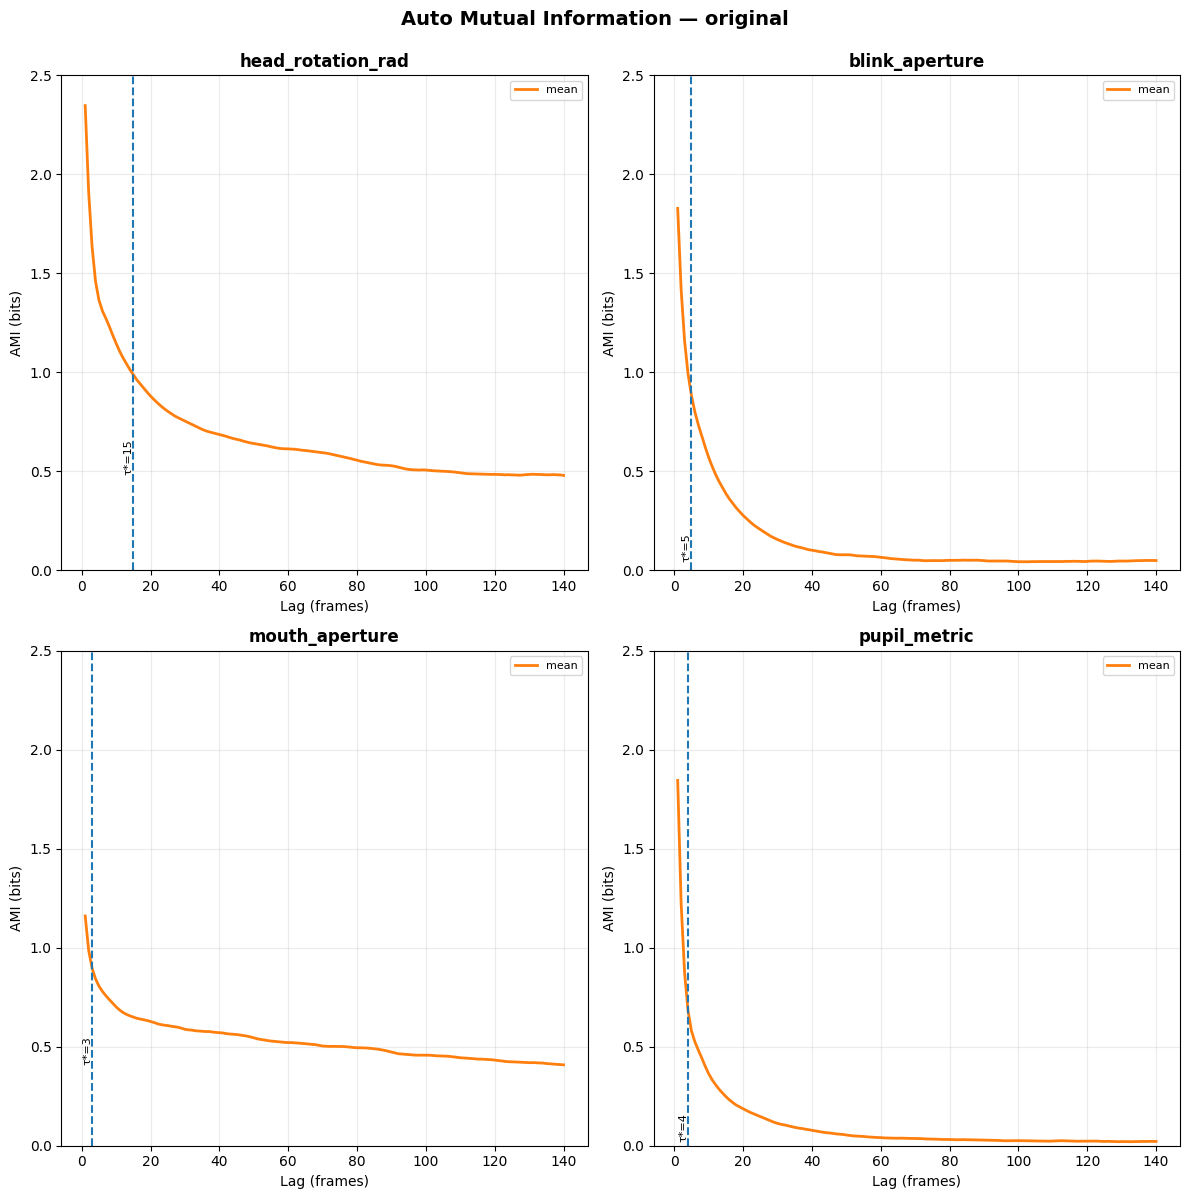

In [3]:
from utils.nl_utils import ami_average_across_features

# use the interactive selection if present, otherwise fall back to the top features
if "SELECTED_FEATURES" in globals() and SELECTED_FEATURES:
    feats = list(SELECTED_FEATURES)
else:
    from utils.nb_utils import feature_columns
    feats = feature_columns(df_all)[:4]

print("Features ->", feats)

# AMI parameters (edit if you want different)
min_lag  = 1
max_lag  = 140
sample_n = 1
strategy = "longest"
seed     = 42

info = ami_average_across_features(
    df_all=df_all,
    features=feats,
    sample_n=sample_n,
    min_lag=min_lag,
    max_lag=max_lag,
    strategy=strategy,
    seed=seed,
    plot=True,           
    ncols=2,
    title_suffix=NORM_KIND,
    verbose=True,
)

print("\n".join(info["summary_lines"]))
# quick peek at combined average if present
if info.get("combined_avg") is not None:
    print("\nCombined avg head:")
    display(info["combined_avg"].head())



## 3. False Nearest Neighbours (FNN)

With τ selected from AMI, we estimate the **minimal embedding dimension** using False Nearest Neighbours (FNN). For each feature, we compute the percentage of points whose nearest neighbours in dimension *d* are no longer neighbours when we embed in *d+1*. The embedding dimension is chosen where %FNN falls near zero (or a small tolerance), and we report **mean ± SEM** across sampled recordings. As with AMI, treat the exact “elbow” conservatively — we care about the scale. We see here that the plateau is around 4. 


FNN on features -> ['blink_aperture', 'mouth_aperture']


/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/matb-analysis/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


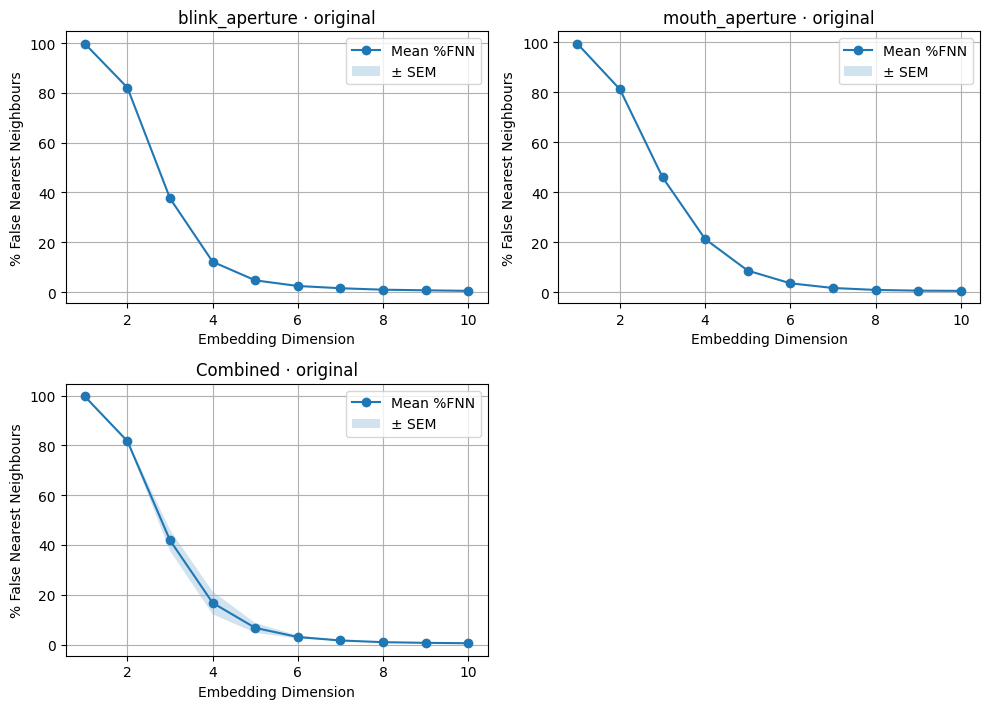

[blink_aperture] 1 rec(s); dims 1..10
[mouth_aperture] 1 rec(s); dims 1..10
[Combined] Averaged across 2 feature-averages.


,dim,fnn_mean,fnn_sem
0,1,99.628277,0.111846
1,2,81.661674,0.411468
2,3,41.826147,4.229388
3,4,16.729292,4.576618
4,5,6.695471,1.995448
5,6,3.026503,0.590779
6,7,1.638099,0.102381
7,8,0.956740,0.008262
8,9,0.687853,0.013228
9,10,0.534432,0.054601


In [4]:
# FNN — lightweight caller using features from Cell 1
from utils.nl_utils import fnn_average_across_features

# features: use interactive selection if available, else fallback
if "SELECTED_FEATURES" in globals() and SELECTED_FEATURES:
    feats = list(SELECTED_FEATURES)
else:
    from utils.nb_utils import feature_columns
    feats = feature_columns(df_all)[:4]

print("FNN on features ->", feats)

# choose tau: if you computed an AMI-based tau, plug it here; else pick a conservative default
TAU = 20  # frames (≈ 0.33 s at 60 Hz). Set from your AMI result if you want.

info_fnn = fnn_average_across_features(
    df_all=df_all,
    features=feats,
    tau=TAU,
    min_dim=1,
    max_dim=10,
    sample_n=1,          # recordings per feature
    strategy="longest",   # or "random"
    seed=42,
    plot=True,
    ncols=2,
    title_suffix=NORM_KIND,
)

print("\n".join(info_fnn["summary_lines"]))
# peek at combined
if info_fnn["combined_avg"] is not None:
    display(info_fnn["combined_avg"])


## 4. Run Auto Recurrence Quantification Analysis (RQA)

Using the same selected features and recordings, we compute windowed **RQA** metrics (e.g., %Recurrence, %Determinism, Entropy, Laminarity) per trial and per feature. Windows match the settings used earlier (length and overlap). Windows containing NaNs (from low-confidence keypoint masking) are skipped. Results are saved to a tidy CSV with identifiers: recording_id, participant, condition, feature, window_index, and the usual RQA statistics for downstream analysis.


In [2]:
# Auto-RQA — run on the selected features from Cell 1, per recording, windowed
from pathlib import Path
from utils.rqa_utils import rqa_over_df_all_features

# Import session settings from Cell 1
from utils import CFG  # if you need FPS/WINDOW_SECONDS

# Construct output path for RQA results
OUT_RQA_DIR = Path("data/rqa")
OUT_RQA_DIR.mkdir(parents=True, exist_ok=True)

OUT_RQA = OUT_RQA_DIR / f"{Path(OUT_BASE).name}_{NORM_KIND}_rqa.csv"

# features: use interactive selection if available; fallback to top detected
if "SELECTED_FEATURES" in globals() and SELECTED_FEATURES:
    feats = list(SELECTED_FEATURES)
else:
    from utils.nb_utils import feature_columns
    feats = feature_columns(df_all)[:6]

print("RQA on features →", feats)

# Params 
RQA_PARAMS = {
    "norm": 1,
    "eDim": 4,
    "tLag": 15,         
    "rescaleNorm": 1,
    "radius": 0.15,
    "tw": 2,
    "minl": 4,
}

WIN_SECONDS  = CFG.WINDOW_SECONDS
OVERLAP_FRAC = CFG.WINDOW_OVERLAP
FPS          = CFG.FPS

out_csv = str(Path(OUT_BASE) / "rqa" / f"{NORM_KIND}_rqa.csv")

rqa_df = rqa_over_df_all_features(
    df_all=df_all,
    features=feats,
    fps=FPS,
    win_seconds=WIN_SECONDS,
    overlap_frac=OVERLAP_FRAC,
    params=RQA_PARAMS,
    out_csv=out_csv,
    progress=True,
)

# quick peek
display(rqa_df.head())


RQA on features → ['head_rotation_rad', 'blink_aperture', 'mouth_aperture', 'pupil_dx', 'pupil_dy', 'pupil_metric', 'center_face_magnitude', 'center_face_x', 'center_face_y']


Recordings: 100%|██████████| 217/217 [52:12<00:00, 14.44s/it] 


[RQA] wrote 60247 rows → data/processed/experimental/rqa/original_rqa.csv


,recording_id,participant,condition,feature,window_index,window_start,window_end,perc_recur,perc_determ,maxl_found,mean_line_length,std_line_length,entropy,laminarity,trapping_time,vmax,divergence,trend_lower_diag,trend_upper_diag
0,402_H_perframe,402,H,head_rotation_rad,0,0,3600,5.734594,91.984290,1146.0,17.736699,34.773665,4.618782,0.952467,22.140798,253.0,0.000873,1.599343,1.599343
1,402_H_perframe,402,H,head_rotation_rad,1,1800,5400,4.606536,89.041473,1296.0,12.971849,24.345823,4.189768,0.935052,16.049603,232.0,0.000772,-1.787477,-1.787477
2,402_H_perframe,402,H,head_rotation_rad,2,3600,7200,3.603239,81.915366,501.0,8.877007,11.470715,3.642284,0.891135,10.856007,98.0,0.001996,-1.828646,-1.828646
3,402_H_perframe,402,H,head_rotation_rad,3,5400,9000,4.737189,88.190216,925.0,10.304282,13.917520,3.972557,0.928585,13.043937,155.0,0.001081,-2.914754,-2.914754
4,402_H_perframe,402,H,head_rotation_rad,4,7200,10800,4.347353,92.984137,1955.0,16.358223,37.001626,4.562521,0.954055,19.382480,396.0,0.000512,-2.179940,-2.179940


## 5. Stats Models and Figure Outputs

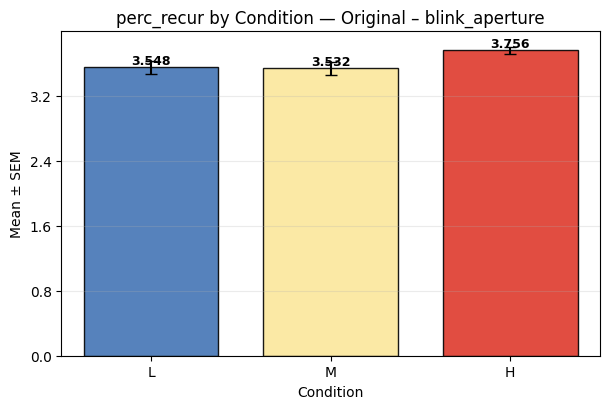

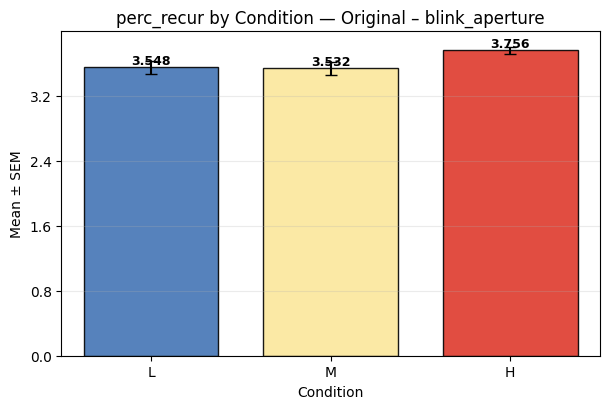

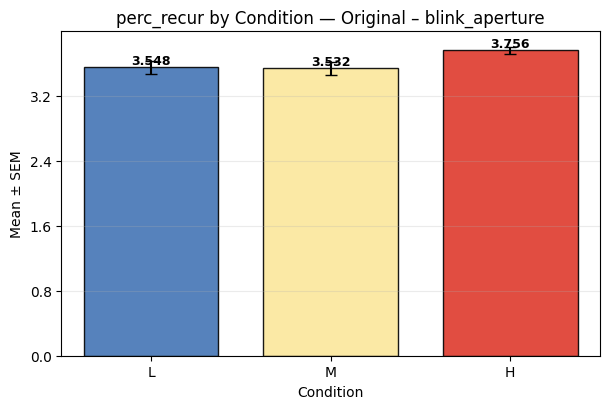

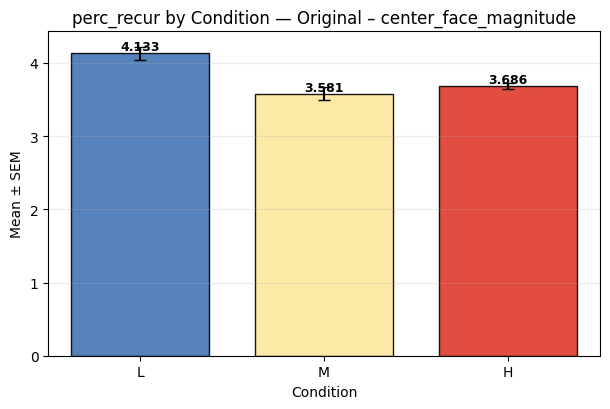

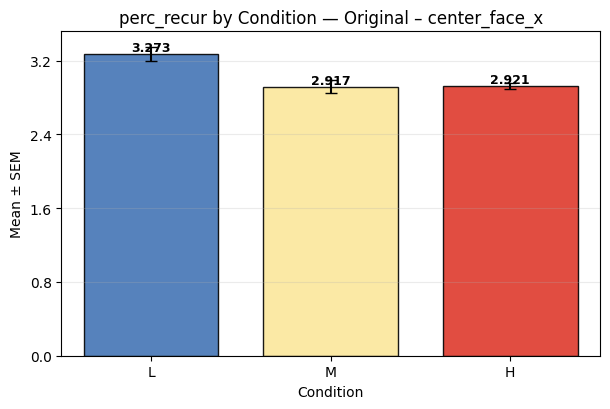

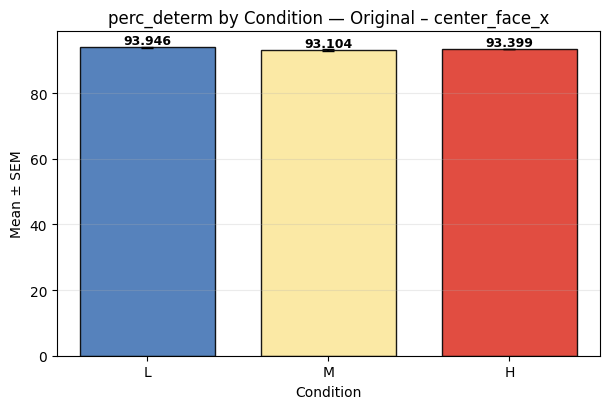

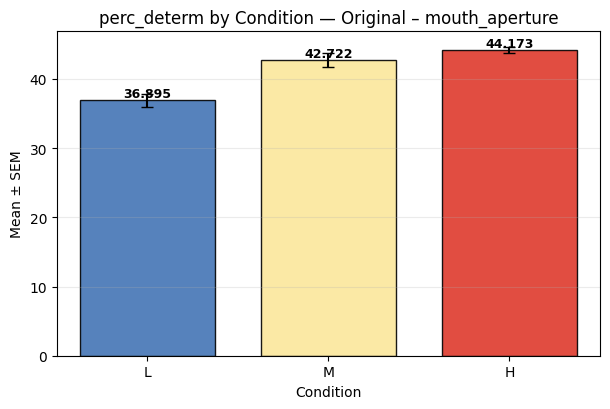

In [7]:
%matplotlib inline
import os
from pathlib import Path
import pandas as pd
from ipywidgets import ToggleButtons, Dropdown, VBox, HBox, Output
from IPython.display import display

from utils.nb_utils import (
    candidate_metric_cols, default_metric, ensure_condition_order,
    bar_by_condition, load_rqa_df
)
from utils.stats_utils import compare_groups_statistical

# --- map to your RQA outputs ---
RQA_BASE = Path(CFG.OUT_BASE) / "rqa"

CSV_MAP_ALL = {
    "Original":                 RQA_BASE / "experimental_original_rqa.csv",
    "Procrustes (Global)":      RQA_BASE / "experimental_procrustes_global_rqa.csv",
    "Procrustes (Participant)": RQA_BASE / "experimental_procrustes_participant_rqa.csv",
}
CSV_MAP = {label: path for label, path in CSV_MAP_ALL.items() if path.exists()}
if not CSV_MAP:
    raise RuntimeError(f"No RQA CSVs found under {RQA_BASE}")

# ---- widgets ----
w_norm    = ToggleButtons(options=list(CSV_MAP.keys()), value=list(CSV_MAP.keys())[0], description="Normalization:")
w_feature = Dropdown(options=[], description="Feature:")   # new dropdown for feature column
w_metric  = Dropdown(options=[], description="Metric:")
w_test    = ToggleButtons(options=["auto", "parametric", "nonparametric"], value="auto", description="Test:")
out_plot  = Output()
out_stats = Output()

def refresh(norm_label):
    df = load_rqa_df(CSV_MAP[norm_label])
    # drop window cols if present
    df = df.drop(columns=[c for c in ["window_start","window_end"] if c in df])

    # fill feature choices from 'feature' column
    if "feature" not in df.columns:
        raise ValueError("Expected 'feature' column in RQA CSV")
    w_feature.options = sorted(df["feature"].unique())

    # set default
    if w_feature.value not in w_feature.options:
        w_feature.value = w_feature.options[0]

    # now restrict to that feature
    df_feat = df[df["feature"] == w_feature.value]

    # fill metric options
    cols = candidate_metric_cols(df_feat)
    w_metric.options = cols
    if cols and (w_metric.value not in cols):
        w_metric.value = default_metric(cols)

def draw(*_):
    out_plot.clear_output(); out_stats.clear_output()
    df = load_rqa_df(CSV_MAP[w_norm.value])
    df = df.drop(columns=[c for c in ["window_start","window_end"] if c in df])

    # filter by feature
    df = df[df["feature"] == w_feature.value]

    if not w_metric.options or w_metric.value not in w_metric.options:
        refresh(w_norm.value)
    metric = w_metric.value
    if metric is None:
        with out_plot: print("No numeric metric found in file."); return

    # plot
    with out_plot:
        bar_by_condition(df, metric, title_suffix=f"{w_norm.value} – {w_feature.value}")

    # stats
    res = compare_groups_statistical(df, metric, test_type=w_test.value)
    with out_stats:
        print(f"Omnibus: {res['omnibus']['name']}  stat={res['omnibus']['stat']:.4f}  p={res['omnibus']['p']:.4g}")
        print(f"Test type: {res['test_type']}\n")
        print("Descriptives (per condition):")
        display(res["descriptives"].style.format({"mean":"{:.4f}","std":"{:.4f}","sem":"{:.4f}","median":"{:.4f}"}))
        if not res["pairwise"].empty:
            print("\nPairwise (Holm–Bonferroni corrected):")
            display(res["pairwise"].style.format({"p_raw":"{:.4g}","p_holm":"{:.4g}"}))
        else:
            print("\nPairwise: (k<=2 or not applicable)")

# wire events
w_norm.observe(lambda ch: (ch["name"]=="value") and (refresh(ch["new"]) or draw()))
w_feature.observe(lambda ch: (ch["name"]=="value") and draw())
w_metric.observe(lambda ch: (ch["name"]=="value") and draw())
w_test.observe(lambda ch: (ch["name"]=="value") and draw())

# init
refresh(w_norm.value); draw()
display(VBox([HBox([w_norm, w_feature, w_metric, w_test]), out_plot, out_stats]))



# Pose Cross Recurrence Quantification Analysis

## Cross Average Mutual Information (Cross-AMI)

## Cross RQA

## Stats and Figure Outputs